# Training SKL & XGB Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading Datasets
train_csv = '../data/train/df_train.csv'
val_csv = '../data/train/df_val.csv'
df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

In [3]:
'''Target Variable Processing'''

target = 'price'
# Preparing the target Variable:
# The  y dataframes contain the Target Variable for training and validation
y_train = df_train[target]
y_val = df_val[target]

# Remove Target from training and validation datasets
X_train = df_train.drop(columns=target)
X_val = df_val.drop(columns=target)

In [4]:
# Defining column types

numerical = X_train.select_dtypes('number').columns.tolist()
categorical = X_train.select_dtypes(include='object').columns.tolist()
multi_label = [
    'comfort_convenience',
    'entertainment_media',
    'extras',
    'safety_security']

categorical = list(set(categorical)-set(multi_label))
categorical, numerical, multi_label

(['gearing_type',
  'fuel',
  'drive_chain',
  'make_model',
  'upholstery_type',
  'body_type',
  'paint_type',
  'vat',
  'type'],
 ['km',
  'gears',
  'age',
  'previous_owners',
  'hp_kw',
  'inspection_new',
  'displacement_cc',
  'weight_kg',
  'cons_comb'],
 ['comfort_convenience', 'entertainment_media', 'extras', 'safety_security'])

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction import DictVectorizer
from sklearn.base import BaseEstimator, TransformerMixin 
from sklearn.metrics import r2_score, root_mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LassoLars
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

from xgboost import XGBRegressor

### Models With Multi-Label Data Included

In [6]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Lasso Regression', LassoLars()),
    ('Decision Tree', DecisionTreeRegressor()),
    ('Gradient Boosting', GradientBoostingRegressor()),
    ('Random Forest', RandomForestRegressor()),
    ('XGB Regressor', XGBRegressor())
    ]

In [7]:
class FlattenMultiLabelColumns(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert each row of the DataFrame into a dictionary;
        # then expand any list columns into multiple {key: 1} entries.
        rows = X[categorical + numerical + multi_label].to_dict(orient='records')
        records = []
        for row in rows:
            new_row = {}
            for col, val in row.items():
                if col in multi_label and isinstance(val, list):
                    # For list columns, create new keys col=item
                    for item in val:
                        new_row[f"{col}={item}"] = 1
                else:
                    # For normal columns, just keep the original key/value
                    new_row[col] = val
            records.append(new_row)
        
        return records

In [8]:
# Preprocessor including multi-label data
preprocessor = Pipeline([
    ('flattern', FlattenMultiLabelColumns()),
    ('vectorizer', DictVectorizer(sparse=False))  # returns dense array
])

In [9]:
def train(model_name,
          model, 
          preprocessor=preprocessor):
    '''Train a model using the provided model.'''
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]
    )
    pipeline.fit(X_train, y_train)

    # Make predictions on validation data
    y_pred = pipeline.predict(X_val)

    # Evaluate the model
    r2 = r2_score(y_val, y_pred)
    rmse = root_mean_squared_error(y_val, y_pred)
    return {
        'model': model_name,
        'r2': round(r2, 3),
        'rmse': round(rmse, 2)
        }

In [10]:
results = [
    train(model_name, model)
    for model_name, model in models
]

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 182 iterations, i.e. alpha=2.117e+00, with an active set of 172 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 192 iterations, i.e. alpha=2.046e+00, with an active set of 182 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 230 iterations, i.e. alpha=1.681e+00, with an active set of 218 regressors,

In [11]:
model_scores = pd.DataFrame(results)
with pd.option_context('display.float_format','{:.2f}'.format):
    print(model_scores)

               model              r2         rmse
0  Linear Regression -10382560295.90 613856322.91
1   Ridge Regression            0.90      1955.55
2   Lasso Regression            0.89      1997.57
3      Decision Tree            0.91      1788.29
4  Gradient Boosting            0.91      1782.09
5      Random Forest            0.94      1422.05
6      XGB Regressor            0.94      1512.92


#### RMSE Interpretation.

Root Mean Square Error (RMSE) is a commonly used metric to evaluate the accuracy of a model's predictions compared to actual values. An RMSE of 1 500 indicates the following:

*Magnitude of Error*: The value of 1 500 represents the average difference between predicted values and actual values, with the differences squared, averaged, and then the square root taken. This means that, on average, the model's predictions deviate from the actual values by about 1 500 units.

*Context Matters*: The interpretation of whether this RMSE is good or bad depends on the context of the data and the specific application. For example, in this car price prediction model the prices range from 4 950 to 35 450. The RMSE indicates that the model (on average) predicted price to be X - give or take 1 500.

*Comparison Tool*: RMSE is useful for comparing different models. A lower RMSE indicates a better fit to the data, so if you're evaluating multiple models, you would prefer the one with the lowest RMSE.


In [12]:
### Models without multi-label columns

In [13]:
class ConvertToDict(BaseEstimator, TransformerMixin):  
    """  
    A simple transformer that converts a pandas DataFrame  
    into a list of dictionaries for use by DictVectorizer.  
    """  
    def fit(self, X, y=None):  
        return self      
    def transform(self, X):  

        return X[categorical + numerical].to_dict(orient='records') 

In [14]:
# Preprocessor Without Multi-label Data
preprocessor_mlt = Pipeline([
    ('convert', ConvertToDict()),
    ('vectorizer', DictVectorizer(sparse=False))  # returns dense array
])

In [15]:
results = [
    train(model_name, model, preprocessor=preprocessor_mlt)
    for model_name, model in models
]

In [16]:
model_scores = pd.DataFrame(results)
with pd.option_context('display.float_format','{:.2f}'.format):
    print(model_scores)

               model   r2    rmse
0  Linear Regression 0.88 2121.98
1   Ridge Regression 0.88 2118.86
2   Lasso Regression 0.88 2114.74
3      Decision Tree 0.90 1912.17
4  Gradient Boosting 0.92 1735.97
5      Random Forest 0.94 1481.75
6      XGB Regressor 0.94 1487.83


The results show that the results including the multilabel data are slightly better. We will use that data for hyperparameter tuning.

## HyperParameter Tunning

Hyperparameter tuning to be perfomed on the three most perfomant models: 

- Gradient Boosting 
- Random Forest
- XGB Regressor

In [17]:
# Define the models and their parameter grids
'''
    'Ridge Regression': {
        'model': Ridge(),
        'params': {
            'classifier__alpha': [0.1, 1.0, 10.0, 100]
        }
    },

    'Decision Tree': {
        'model': DecisionTreeRegressor(),
        'params': {
            'classifier__max_depth':  [None, 5, 10, 15, 20],
            'classifier__min_samples_split': range(5,21,5)
        }
    },

    'Linear Regression': {
        'model': LinearRegression(),
        'params': {
            'classifier__fit_intercept': [True, False]
        }
    },

    'Lasso Regression': {
        'model': LassoLars(),
        'params': {
            'classifier__alpha': [0.1, 1.0, 10.0],
            'classifier__max_iter': [1000, 5000]
        }
    }

'''
models = {
    'Random Forest': {
        'model': RandomForestRegressor(),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5, 10]
        }
    },
    'Gradient Boosting': {
        'model':  GradientBoostingRegressor(),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.1, 0.2, 0.5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(objective='reg:squarederror'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.1, 0.2, 0.5],
            'classifier__max_depth': [3, 5, 10]
        }
    }  
}

In [18]:
from sklearn.model_selection import GridSearchCV

def grid_train(model_name, model_info):
    pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_info['model'])
        ]
    )
    
    grid_search = GridSearchCV(
        pipeline, 
        model_info['params'],
        scoring='neg_root_mean_squared_error',
        verbose=1 
        )
        
    grid_search.fit(X_train, y_train)
    
    # Best model from Grid Search
    best_model = grid_search.best_estimator_
    
    # Evaluate on the validation set
    y_pred = best_model.predict(X_val)
     # Evaluate the model
    r2 = r2_score(y_val, y_pred)
    rmse = root_mean_squared_error(y_val, y_pred)
    
    return {
        'model': model_name,
        'r2': round(r2, 3),
        'rmse': round(rmse, 2),
        'best_params': grid_search.best_params_
    }

    

In [ ]:
# Train and evaluate each model
results = [
    grid_train(model_name, model_info)
    for model_name, model_info in models.items()
] 

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [20]:
import pprint
pprint.pp(results)

[{'model': 'Linear Regression', 'r2': 0.876, 'rmse': np.float64(2121.98)},
 {'model': 'Ridge Regression', 'r2': 0.876, 'rmse': np.float64(2118.86)},
 {'model': 'Lasso Regression', 'r2': 0.877, 'rmse': np.float64(2114.74)},
 {'model': 'Decision Tree', 'r2': 0.901, 'rmse': np.float64(1892.84)},
 {'model': 'Gradient Boosting', 'r2': 0.917, 'rmse': np.float64(1735.97)},
 {'model': 'Random Forest', 'r2': 0.94, 'rmse': np.float64(1475.12)},
 {'model': 'XGB Regressor', 'r2': 0.939, 'rmse': np.float64(1487.83)}]


In [21]:
best_model_scores = pd.DataFrame(results, columns=['model', 'r2', 'rmse'])
with pd.option_context('display.float_format','{:.2f}'.format):
    print(best_model_scores)

               model   r2    rmse
0  Linear Regression 0.88 2121.98
1   Ridge Regression 0.88 2118.86
2   Lasso Regression 0.88 2114.74
3      Decision Tree 0.90 1892.84
4  Gradient Boosting 0.92 1735.97
5      Random Forest 0.94 1475.12
6      XGB Regressor 0.94 1487.83


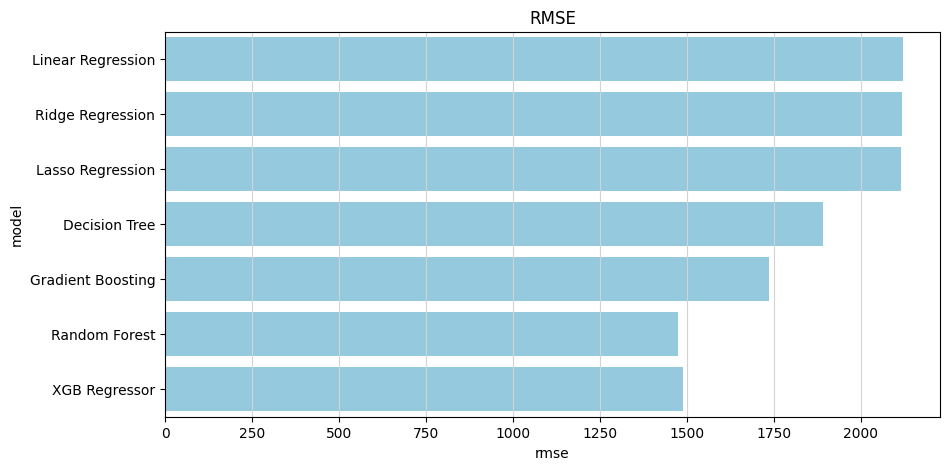

In [32]:
# Plot a bar graph showing the performance of the models.
best = best_model_scores[['model','rmse']]
plt.figure(figsize=(5, 5))
sns.barplot(
    y=best['model'], 
    x=best['rmse'], 
    color='skyblue')
plt.grid(
    axis='x',
    color='lightgrey')
# plt.xlim(0.5, 0.75)
plt.title("RMSE")
plt.show()


## Best Model

The best Model is XGBoost, with the following parameters:

In [ ]:
pprint.pp(results[5])